In [2]:
import pandas as pd
import os

folder_path = r'C:\Users\DELL\Downloads'
file_name = 'Customer_Churn_Dataset.xlsx'

df = pd.read_excel(os.path.join(folder_path, file_name))
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


# 1. Create the helper columns needed for the insights
# This converts 'Yes'/'No' to 1 and 0 so the math works
df['ChurnRate'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Create df_clean (used in your Contract Type plot)
df_clean = df.dropna()

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn,ChurnRate
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,0,No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes,1


In [4]:
# Check for data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:


# 1. Handling 'TotalCharges' - converting to numeric and fixing blank spaces
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Check for missing values created by the conversion
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# 3. Fill missing TotalCharges with the median (or drop them since it's a small amount)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 4. Convert SeniorCitizen to 'Yes'/'No' for better readability in plots
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("Data Cleaning Complete!")

Missing values in TotalCharges: 11
Data Cleaning Complete!


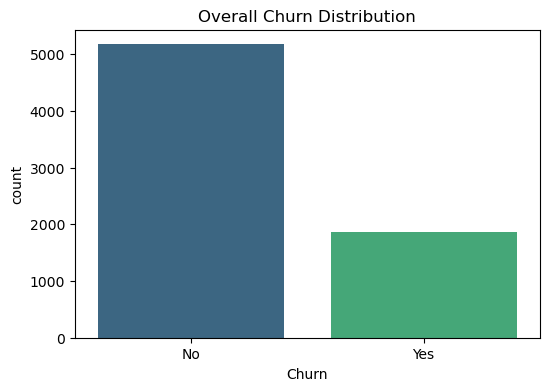

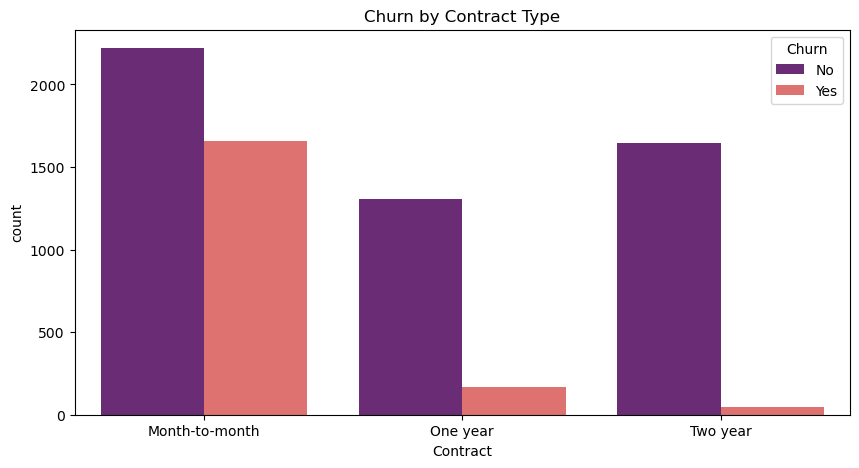

In [6]:
# Visualizing Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn',hue='Churn' , data=df, palette='viridis')
plt.title('Overall Churn Distribution')
plt.show()

# Churn by Contract Type (This is usually a huge driver of churn)
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')
plt.title('Churn by Contract Type')
plt.show()

Ellipsis

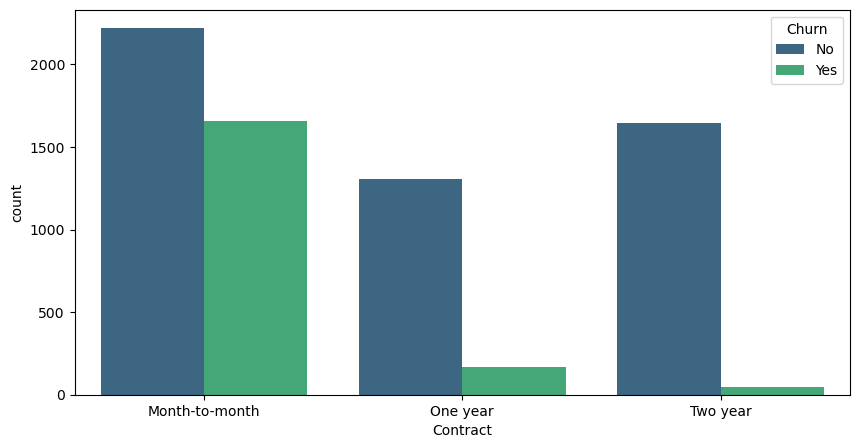

In [7]:
# Add this line before your plot code
df_clean = df.dropna() 

# Now your original code will work
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df_clean, palette='viridis')
...

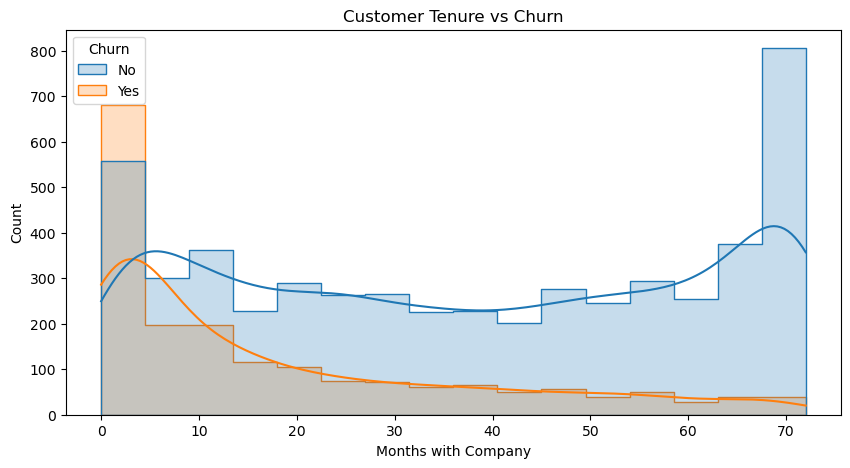

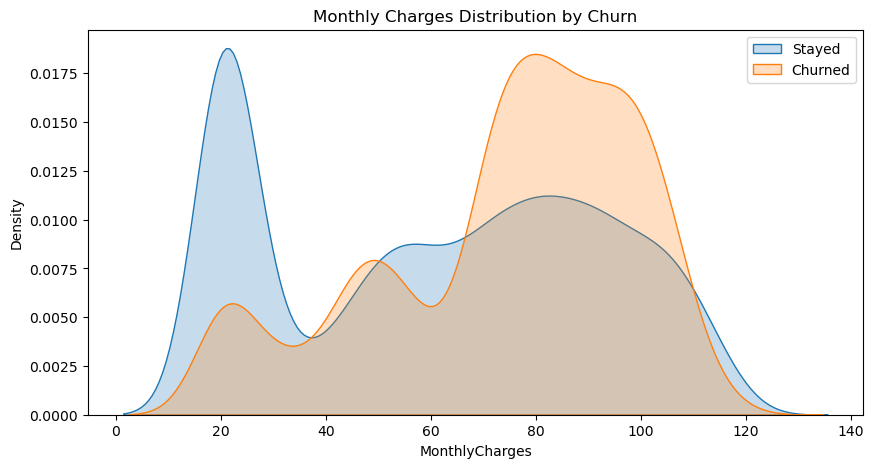

In [8]:
# Relationship between Tenure and Churn
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, element="step")
plt.title('Customer Tenure vs Churn')
plt.xlabel('Months with Company')
plt.show()

# Monthly Charges distribution
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['Churn'] == 'No']['MonthlyCharges'], label='Stayed', fill=True)
sns.kdeplot(df[df['Churn'] == 'Yes']['MonthlyCharges'], label='Churned', fill=True)
plt.title('Monthly Charges Distribution by Churn')
plt.legend()
plt.show()

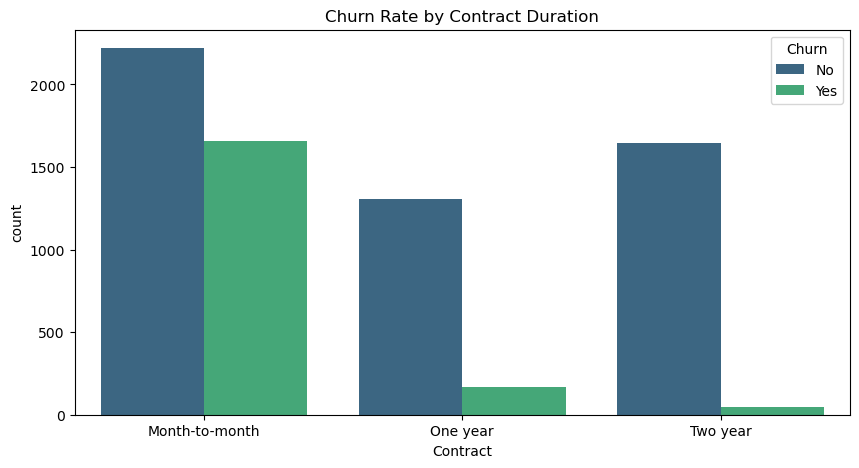

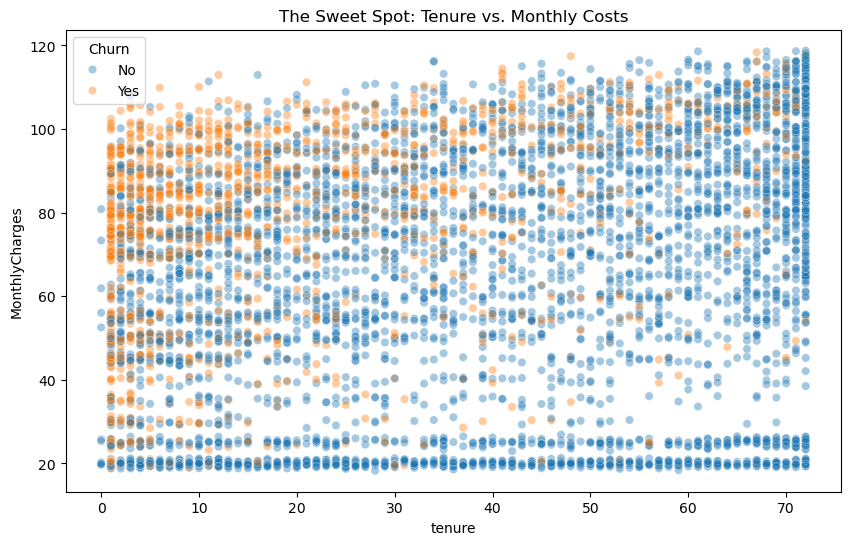

In [9]:
# Churn by Contract Type
plt.figure(figsize=(10,5))
sns.countplot(x='Contract', hue='Churn', data=df_clean, palette='viridis')
plt.title('Churn Rate by Contract Duration')
plt.show()

# Tenure vs Monthly Charges
plt.figure(figsize=(10,6))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df_clean, alpha=0.4)
plt.title('The Sweet Spot: Tenure vs. Monthly Costs')
plt.show()

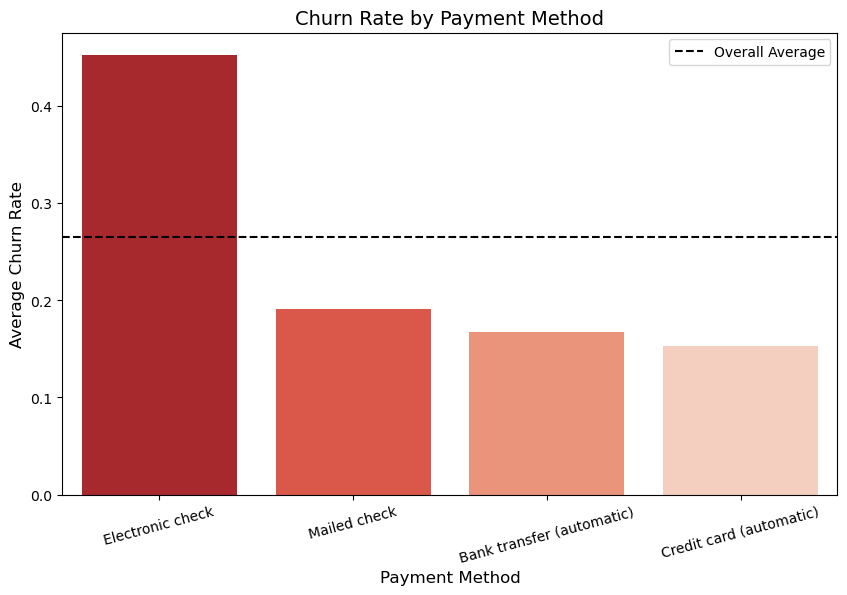

In [10]:
# --- Insight 4: Payment Method Friction ---

# 1. Calculate the Churn Rate for each payment method
payment_analysis = df.groupby('PaymentMethod')['ChurnRate'].mean().sort_values(ascending=False)

# 2. Create the Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=payment_analysis.index, 
    y=payment_analysis.values, 
    hue=payment_analysis.index, # Assigning 'hue' fixes the warning
    palette='Reds_r', 
    legend=False                # Hides the extra legend
        )

# 3. Add Labels
plt.title('Churn Rate by Payment Method', fontsize=14)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Average Churn Rate', fontsize=12)
plt.xticks(rotation=15)

# Add the baseline average line
plt.axhline(df['ChurnRate'].mean(), color='black', 
            linestyle='--', label='Overall Average')
plt.legend()

plt.show()

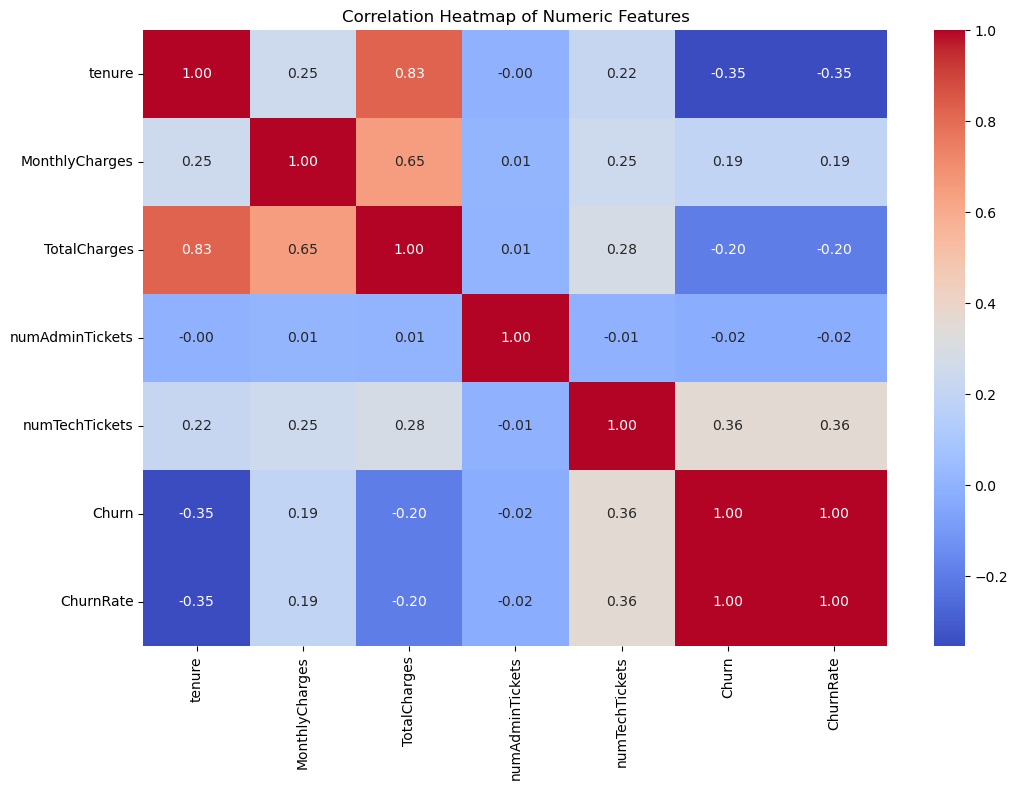

In [11]:
# Convert Churn to binary for correlation analysis
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Select only numeric columns for the heatmap
numeric_df = df_corr.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [ ]:
 # 1. The "Contract" Trap
The most significant finding is that Contract Type is the primary predictor of churn.
    Customers on Month-to-Month plans are significantly more likely to leave compared 
to those on one or two-year contracts.

Insight: Monthly plans offer flexibility to the customer but represent high risk for
the business.

Action: Encouraging users to switch to longer contracts through targeted incentives 
could stabilize long-term revenue.

In [ ]:
 #2. Tenure and the 90-Day Window
The "Tenure vs. Churn" analysis reveals a clear trend: the longer a customer stays,
the less likely they are to leave. Most churn occurs within the first 6 months of
service. Once a customer passes the one-year mark, they become significantly more 
"sticky" and loyal.

Insight: The business should focus its marketing and customer success efforts heavily
on new users during their first 90 days.

Action: Implement a robust onboarding program to ensure value is realized early in the
customer lifecycle.

In [ ]:
 # 3. The "Payment Friction" InsightCustomers using Electronic Check payments show a churn 
rate near 45%, while those on Automatic Credit Card or Bank Transfers usually stay
around 15-20%.
    
The Insight: Manual payments require a customer to make a conscious decision to pay 
every month. This "friction" creates a monthly opportunity for them to rethink their
subscription. Automatic payments make the service "invisible," leading to higher 
retention.
    
Actionable Strategy: The business should incentivize the switch to auto-pay
    (e.g., "Save $5 a month by switching to Auto-pay"). This removes the monthly 
    decision point and reduces accidental churn due to missed payments.